# Notebook 05 — Final Visualizations

This notebook produces all charts and interactive maps for the final project.

## 0. Imports and shared configuration

In [45]:
from __future__ import annotations
 
from pathlib import Path
 
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from helper_functions import safe_wkt_load
from shapely import wkt
 
PROCESSED = Path("../data/processed")
VIZ       = Path("../visualizations")
VIZ.mkdir(exist_ok=True)
 
SELECTED_ROUTES = ["22", "Rapid 522", "23", "Rapid 523", "25", "60"]
 
# Shared style
BG_FIG   = "#1b1b1b"
BG_AX    = "#1e1e1e"
GRID_CLR = "#2e2e2e"
SPINE    = "#3a3a3a"
ZERO_CLR = "#555555"
EBAR_CLR = "#cccccc"
TEXT1    = "#e8e8e8"
TEXT2    = "#b0b0b0"
TEXT3    = "#777777"
C_LOCAL  = "#c94f2a"
C_RAPID  = "#5b8db8"

plt.rcParams.update({
    "font.family":     "Georgia",
    "axes.labelcolor": TEXT2,
    "font.size":          10,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     9.5,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.edgecolor":     SPINE,
    "axes.linewidth":     0.6,
    "xtick.color":        TEXT2,
    "ytick.color":        TEXT2,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "xtick.major.size":   0,
    "ytick.major.size":   0,
    "figure.facecolor":   BG_FIG,
    "axes.facecolor":     BG_AX,
    "grid.color":         GRID_CLR,
    "grid.linewidth":     0.5,
    "text.color":         TEXT1,
    "axes.titlepad":      24,
    "axes.titlelocation": "left",
})
 
print("Imports complete.")

Imports complete.


## 1. Load processed data

In [46]:
# Delay records (one row per trip-stop observation)
delay_raw = pd.read_csv(PROCESSED / "cleaned_delay_data.csv")

# Stop-level ridership
ridership = pd.read_csv(PROCESSED / "selected_station_ridership.csv")
ridership["direction_id"] = ridership["direction_id"] % 10

# Unified stop-level table (spacing + delay + ridership, all routes)
station_spacings = pd.read_csv(PROCESSED / "station_spacings.csv")
station_spacings["geometry"] = station_spacings["geometry"].apply(safe_wkt_load)
gdf = gpd.GeoDataFrame(station_spacings, geometry="geometry", crs="EPSG:2227").to_crs("EPSG:4326")
gdf["lat"] = gdf.geometry.y
gdf["lon"] = gdf.geometry.x
gdf["spacing_m"] = (gdf["spacing_ft"] * 0.3048).round(1)
gdf["mean_delay_sec"] = gdf["mean_delay"].round(1)
gdf["boardings_rounded"] = gdf["boardings"].round(1)
gdf["route_label"] = "Route " + gdf["route_id"].astype(str)

# ADT-joined table (San José stops only)
sj_adt = pd.read_csv(PROCESSED / "station_spacings_with_adt.csv")
sj_adt["geometry"] = sj_adt["geometry"].apply(safe_wkt_load)
adt_gdf = gpd.GeoDataFrame(sj_adt, geometry="geometry", crs="EPSG:2227").to_crs("EPSG:4326")
adt_gdf["lat"] = adt_gdf.geometry.y
adt_gdf["lon"] = adt_gdf.geometry.x

print(f"station_spacings: {len(gdf)} rows")
print(f"sj_adt: {len(adt_gdf)} rows")
gdf[["stop_name", "route_id", "mean_delay_sec", "boardings_rounded", "spacing_m"]].head(3)

station_spacings: 710 rows
sj_adt: 255 rows


,stop_name,route_id,mean_delay_sec,boardings_rounded,spacing_m
0,El Camino & Palm,22,79.4,12.8,212.5
1,El Camino & Galvez,22,56.6,66.5,107.3
2,El Camino & Sam McDonald,22,15.4,4.6,113.4


## 2. Figure 1 — Mean Arrival Delay by Route

Horizontal bar chart with 95% confidence intervals and per-bar sample size.
A horizontal layout avoids angled x-axis labels and allows route names to be read easily.

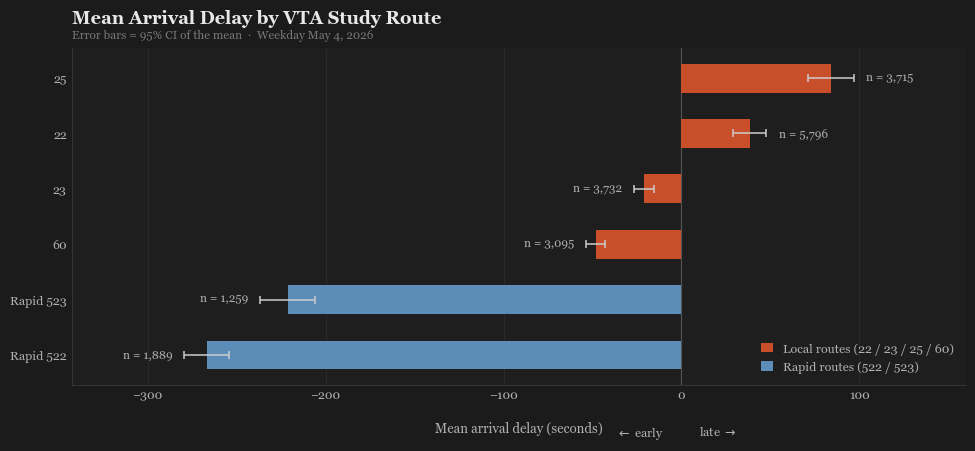

Saved: fig_01_mean_delay_by_route.png
Saved: fig_01_mean_delay_by_route.svg


In [52]:
route_stats = []
for rid in SELECTED_ROUTES:
    sub = delay_raw.loc[delay_raw["route_id"].astype(str) == rid, "computed_delay_sec"].dropna()
    if sub.empty:
        continue
    n    = len(sub)
    mean = sub.mean()
    ci95 = 1.96 * sub.std(ddof=1) / np.sqrt(n)
    route_stats.append({"route_id": rid, "n": n, "mean": mean, "ci95": ci95})
 
stats_df = pd.DataFrame(route_stats).sort_values("mean")
colors   = [C_RAPID if "Rapid" in str(r) else C_LOCAL for r in stats_df["route_id"]]
 
fig1, ax = plt.subplots(figsize=(10, 4.8))
 
bars = ax.barh(
    stats_df["route_id"], stats_df["mean"],
    xerr=stats_df["ci95"], color=colors, height=0.52, edgecolor="none",
    error_kw={"ecolor": EBAR_CLR, "elinewidth": 1.1, "capsize": 3, "capthick": 1.1},
    zorder=3,
)
 
x_range = (stats_df["mean"] + stats_df["ci95"]).max() - (stats_df["mean"] - stats_df["ci95"]).min()
offset  = x_range * 0.018
for bar, row in zip(bars, stats_df.itertuples()):
    x  = bar.get_width()
    tx = x + row.ci95 + offset if x >= 0 else x - row.ci95 - offset
    ax.text(tx, bar.get_y() + bar.get_height() / 2,
            f"n = {row.n:,}", va="center", ha="left" if x >= 0 else "right",
            fontsize=8.5, color=TEXT2)
 
ax.axvline(0, color=ZERO_CLR, linewidth=0.85, zorder=2)
ax.grid(axis="x", zorder=0)
 
pad = x_range * 0.16
ax.set_xlim(stats_df["mean"].min() - stats_df["ci95"].max() - pad,
            stats_df["mean"].max() + stats_df["ci95"].max() + pad)
 
ax.set_xlabel("Mean arrival delay (seconds)", fontsize=9.5, color=TEXT2, labelpad=14)

xmin, xmax = ax.get_xlim()
zero_frac = (0 - xmin) / (xmax - xmin)

ax.text(zero_frac - 0.02, -0.12, r"$\leftarrow$ early",
        transform=ax.transAxes, fontsize=9, color=TEXT2, ha="right", va="top")
ax.text(zero_frac + 0.02, -0.12, r"late $\rightarrow$",
        transform=ax.transAxes, fontsize=9, color=TEXT2, ha="left", va="top")

ax.set_ylabel("")
 
legend_handles = [
    Patch(facecolor=C_LOCAL, edgecolor="none", label="Local routes (22 / 23 / 25 / 60)"),
    Patch(facecolor=C_RAPID, edgecolor="none", label="Rapid routes (522 / 523)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9,
          frameon=False, labelcolor=TEXT2, handlelength=1.0, handleheight=0.8)
 
ax.set_title("Mean Arrival Delay by VTA Study Route", loc="left", pad=18, color=TEXT1)
ax.text(0, 1.02, "Error bars = 95% CI of the mean  \u00b7  Weekday May 4, 2026",
        transform=ax.transAxes, fontsize=8.5, color=TEXT3, ha="left", va="bottom")
 
fig1.tight_layout(pad=1.6)
fig1.savefig(VIZ / "fig_01_mean_delay_by_route.png", dpi=200,
             bbox_inches="tight", facecolor=fig1.get_facecolor())
fig1.savefig(VIZ / "fig_01_mean_delay_by_route.svg",
             bbox_inches="tight", facecolor=fig1.get_facecolor())
plt.show()
print("Saved: fig_01_mean_delay_by_route.png")
print("Saved: fig_01_mean_delay_by_route.svg")

## 3. Figure 2 — Top 20 Delay Hotspot Stops

Horizontal bar chart ranking the 20 stops with the highest mean delay.
Colored by route to reveal which corridors contribute most to the hotspot list.

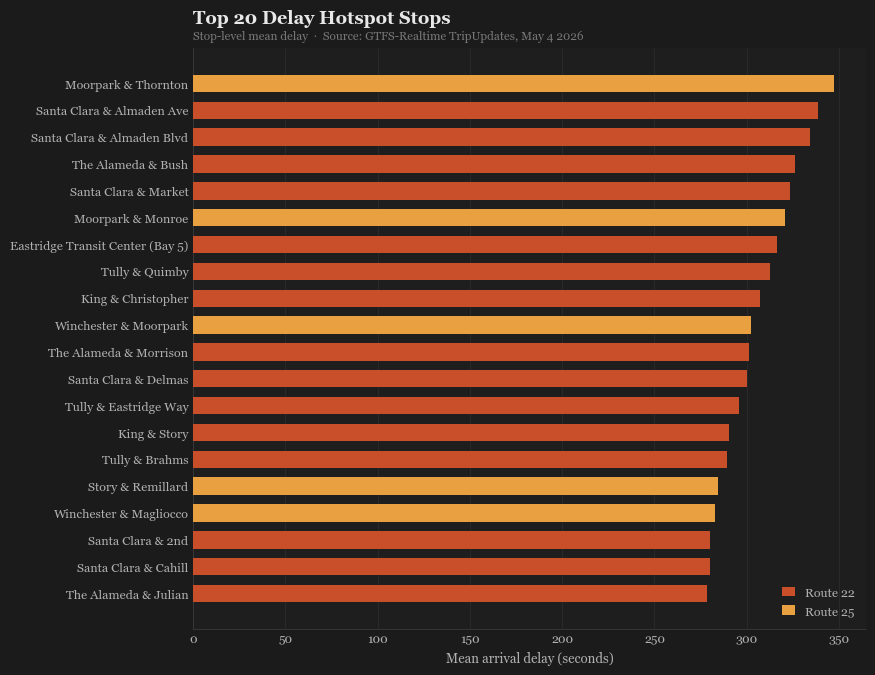

Saved: fig_02_top20_delay_hotspots.svg


In [55]:
top20 = gdf.nlargest(20, "mean_delay_sec")[["stop_name", "route_id", "mean_delay_sec"]].iloc[::-1]
 
# Route 22 and 25 are both local but need visual distinction
route_palette = {"22": C_LOCAL, "25": "#e8a040"}
colors2 = [route_palette.get(str(r), C_LOCAL) for r in top20["route_id"]]
 
fig2, ax = plt.subplots(figsize=(9, 7))
 
ax.barh(top20["stop_name"], top20["mean_delay_sec"],
        color=colors2, height=0.65, edgecolor="none", zorder=3)
 
ax.grid(axis="x", zorder=0)
ax.set_xlabel("Mean arrival delay (seconds)")
ax.set_ylabel("")
 
present_routes = sorted(top20["route_id"].unique())
legend_elements = [
    Patch(facecolor=route_palette.get(str(k), C_LOCAL), edgecolor="none", label=f"Route {k}")
    for k in present_routes
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9,
          frameon=False, labelcolor=TEXT2, handlelength=1.0, handleheight=0.8)
 
ax.set_title("Top 20 Delay Hotspot Stops", loc="left", pad=18, color=TEXT1)
ax.text(0, 1.01, "Stop-level mean delay  \u00b7  Source: GTFS-Realtime TripUpdates, May 4 2026",
        transform=ax.transAxes, fontsize=8.5, color=TEXT3, ha="left", va="bottom")
 
fig2.tight_layout(pad=1.6)
fig2.savefig(VIZ / "fig_02_top20_delay_hotspots.svg",
             bbox_inches="tight", facecolor=fig2.get_facecolor())
fig2.savefig(VIZ / "fig_02_top20_delay_hotspots.png", dpi=200,
             bbox_inches="tight", facecolor=fig2.get_facecolor())
plt.show()
print("Saved: fig_02_top20_delay_hotspots.svg")
 

## 4. Figure 3 — Moving Speed Distribution by Route

Box plots of vehicle speed filtered to moving-only pings (> 0.5 m/s).
Box plots show median, IQR, and outliers — more informative than means alone for skewed speed data.

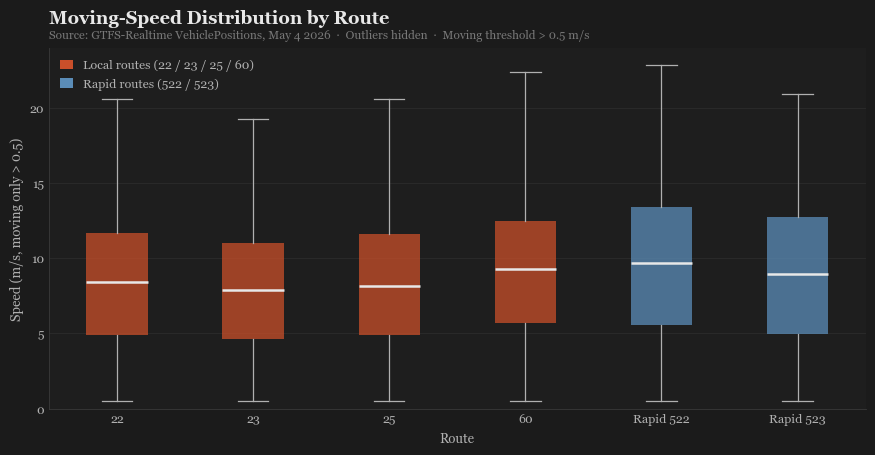

Saved: fig_03_moving_speed_by_route


In [56]:
vehicle = pd.read_csv(PROCESSED / "vehicle_points_filtered_buffer250ft.csv")
vehicle["route_id"] = vehicle["route_id"].astype(str)
vehicle["speed"]    = pd.to_numeric(vehicle["speed"], errors="coerce")
vehicle = vehicle.dropna(subset=["speed"])
vehicle_moving = vehicle[vehicle["speed"] > 0.5].copy()

route_order = ["22", "23", "25", "60", "Rapid 522", "Rapid 523"]
groups = [vehicle_moving.loc[vehicle_moving["route_id"] == r, "speed"].dropna()
          for r in route_order]

fig3, ax = plt.subplots(figsize=(9, 4.8))

bp = ax.boxplot(
    groups, vert=True, patch_artist=True, widths=0.45, showfliers=False,
    medianprops={"color": TEXT1,   "linewidth": 1.8},
    whiskerprops={"color": TEXT2,  "linewidth": 0.9},
    capprops=    {"color": TEXT2,  "linewidth": 0.9},
    boxprops=    {"linewidth": 0.8},
)

for i, patch in enumerate(bp["boxes"]):
    rid = route_order[i]
    patch.set_facecolor(C_RAPID if "Rapid" in rid else C_LOCAL)
    patch.set_alpha(0.75)
    patch.set_edgecolor("none")

ax.set_xticks(range(1, len(route_order) + 1))
ax.set_xticklabels(route_order)
ax.set_xlabel("Route")
ax.set_ylabel("Speed (m/s, moving only > 0.5)")
ax.set_ylim(bottom=0)
ax.grid(axis="y", zorder=0)

ax.set_title("Moving-Speed Distribution by Route", loc="left", pad=18, color=TEXT1)
ax.text(0, 1.02,
        "Source: GTFS-Realtime VehiclePositions, May 4 2026  \u00b7  Outliers hidden  \u00b7  Moving threshold > 0.5 m/s",
        transform=ax.transAxes, fontsize=8.5, color=TEXT3, ha="left", va="bottom")

legend_handles = [
    Patch(facecolor=C_LOCAL, edgecolor="none", label="Local routes (22 / 23 / 25 / 60)"),
    Patch(facecolor=C_RAPID, edgecolor="none", label="Rapid routes (522 / 523)"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9,
          frameon=False, labelcolor=TEXT2, handlelength=1.0, handleheight=0.8)

fig3.tight_layout(pad=1.6)
fig3.savefig(VIZ / "fig_03_moving_speed_by_route.svg",
             bbox_inches="tight", facecolor=fig3.get_facecolor())
fig3.savefig(VIZ / "fig_03_moving_speed_by_route.png", dpi=200,
             bbox_inches="tight", facecolor=fig3.get_facecolor())
plt.show()
print("Saved: fig_03_moving_speed_by_route")

## 5. Figure 4 — Stop/Idle Share by Route

Bar chart of the share of vehicle pings with speed < 0.5 m/s per route.
This serves as a proxy for stop-and-go friction, remaining informative even when delay matching is incomplete.

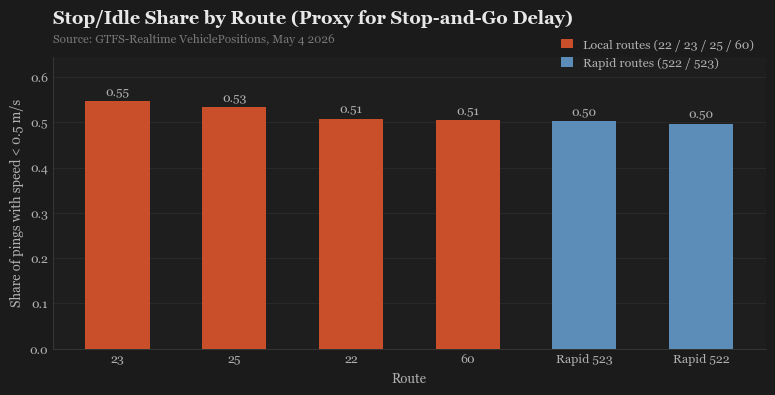

Saved: fig_04_stop_idle_share_by_route


In [64]:
vehicle["is_stopped"] = vehicle["speed"] < 0.5
idle_share = (vehicle.groupby("route_id")["is_stopped"].mean()
              .reset_index().rename(columns={"is_stopped": "stop_share"}))
idle_share = idle_share[idle_share["route_id"].isin(route_order)]
idle_share = idle_share.sort_values("stop_share", ascending=False)

colors4 = [C_RAPID if "Rapid" in str(r) else C_LOCAL for r in idle_share["route_id"]]

fig4, ax = plt.subplots(figsize=(8, 4.2))

bars = ax.bar(idle_share["route_id"], idle_share["stop_share"],
              color=colors4, width=0.55, edgecolor="none", zorder=3)

for bar, val in zip(bars, idle_share["stop_share"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.006,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9, color=TEXT2)

ax.set_xlabel("Route")
ax.set_ylabel("Share of pings with speed < 0.5 m/s")
ax.set_ylim(0, idle_share["stop_share"].max() * 1.18)
ax.grid(axis="y", zorder=0)

legend_handles = [
    Patch(facecolor=C_LOCAL, edgecolor="none", label="Local routes (22 / 23 / 25 / 60)"),
    Patch(facecolor=C_RAPID, edgecolor="none", label="Rapid routes (522 / 523)"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9,
          frameon=False, labelcolor=TEXT2, handlelength=1.0, handleheight=0.8,
          bbox_to_anchor=(1, 1.10))

ax.set_title("Stop/Idle Share by Route (Proxy for Stop-and-Go Delay)", color=TEXT1)
ax.text(0, 1.04, "Source: GTFS-Realtime VehiclePositions, May 4 2026",
        transform=ax.transAxes, fontsize=8.5, color=TEXT3, ha="left", va="bottom")

fig4.tight_layout(pad=1.6)
fig4.savefig(VIZ / "fig_04_stop_idle_share_by_route.svg",
             bbox_inches="tight", facecolor=fig4.get_facecolor())
fig4.savefig(VIZ / "fig_04_stop_idle_share_by_route.png", dpi=200,
             bbox_inches="tight", facecolor=fig4.get_facecolor())
plt.show()
print("Saved: fig_04_stop_idle_share_by_route")

## 6. Figure 5 — Stop Spacing Distribution Map (Interactive)

Plotly Express point map showing stop spacing in feet at each stop.
Color encodes distance to preceding stop (yellow = long, purple = short).
Provides spatial context for RQ1.

In [73]:
def haversine_ft(lat1, lon1, lat2, lon2):
    R = 20902231
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi  = np.radians(lat2 - lat1)
    dlam  = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))
 
segments = []
for (rid, did), grp in gdf.groupby(["route_id", "direction_id"]):
    grp = grp.sort_values("stop_sequence").reset_index(drop=True)
    for i in range(1, len(grp)):
        lat1, lon1 = grp.iloc[i-1]["lat"], grp.iloc[i-1]["lon"]
        lat2, lon2 = grp.iloc[i]["lat"],   grp.iloc[i]["lon"]
        geo_dist   = haversine_ft(lat1, lon1, lat2, lon2)
        if 50 < geo_dist < 5000:
            segments.append({
                "lat1": lat1, "lon1": lon1, "lat2": lat2, "lon2": lon2,
                "spacing_ft": geo_dist, "route_id": rid,
            })
 
seg_df = pd.DataFrame(segments)
print(f"Segments: {len(seg_df)} | Range: "
      f"{seg_df['spacing_ft'].min():.0f}–{seg_df['spacing_ft'].max():.0f} ft")
 

Segments: 562 | Range: 348–4899 ft


In [77]:
LOCAL_ROUTES = [22, 23, 25, 60]
RAPID_ROUTES = [522, 523]
 
bins       = [0, 600, 1000, 1500, 2500, 1e9]
labels     = ["< 600 ft", "600–1000 ft", "1000–1500 ft", "1500–2500 ft", "> 2500 ft"]
colors     = ["#8b0000", "#c0392b", "#e06b3a", "#e8a040", "#d0d0d0"]
bin_widths = {"< 600 ft": 5, "600–1000 ft": 4, "1000–1500 ft": 3,
              "1500–2500 ft": 2.5, "> 2500 ft": 2}
 
seg_df["bin"] = pd.cut(seg_df["spacing_ft"], bins=bins, labels=labels)
 
routes = gpd.read_file("../data/raw/Routes_October_2025.geojson").to_crs("EPSG:4326")
 
def make_spacing_map(seg_df, route_list, title_label):
    sub_seg    = seg_df[seg_df["route_id"].isin(route_list)].copy()
    sub_stops  = gdf[gdf["route_id"].isin(route_list)]
    sub_routes = routes[routes["lineabbr"].isin([str(r) for r in route_list])]
 
    fig = go.Figure()
 
    # Route outlines (faint background lines)
    route_lats, route_lons = [], []
    for _, row in sub_routes.iterrows():
        geom  = row.geometry
        parts = [geom] if geom.geom_type == "LineString" else list(geom.geoms)
        for part in parts:
            coords = list(part.coords)
            route_lats.extend([c[1] for c in coords] + [None])
            route_lons.extend([c[0] for c in coords] + [None])
 
    fig.add_trace(go.Scattermap(
        lat=route_lats, lon=route_lons, mode="lines",
        line=dict(width=1.2, color="rgba(255,255,255,0.12)"),
        hoverinfo="skip", showlegend=False,
    ))
 
    # Spacing segments colored by bin
    for label, color in zip(labels, colors):
        sub = sub_seg[sub_seg["bin"] == label]
        if sub.empty:
            continue
        lats, lons = [], []
        for _, row in sub.iterrows():
            lats.extend([row["lat1"], row["lat2"], None])
            lons.extend([row["lon1"], row["lon2"], None])
        fig.add_trace(go.Scattermap(
            lat=lats, lon=lons, mode="lines",
            line=dict(width=bin_widths[label], color=color),
            name=label, hoverinfo="skip", showlegend=True,
        ))
 
    # Stop markers
    fig.add_trace(go.Scattermap(
        lat=sub_stops["lat"], lon=sub_stops["lon"], mode="markers",
        marker=dict(size=3, color="#5bc8c8", opacity=0.8),
        text=sub_stops.apply(
            lambda r: (f"<b>{r['stop_name']}</b><br>Route {r['route_id']}<br>"
                       f"Spacing: {r['spacing_ft']:.0f} ft"
                       if pd.notna(r["spacing_ft"])
                       else f"<b>{r['stop_name']}</b><br>Route {r['route_id']}"),
            axis=1,
        ),
        hoverinfo="text",
        name="Bus stops",
        showlegend=True,
    ))
 
    fig.update_layout(
        map=dict(
            style="white-bg",
            layers=[dict(
                below="traces", sourcetype="raster",
                source=["https://a.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}.png"],
                opacity=1.0,
            )],
            center={"lat": sub_stops["lat"].mean(), "lon": sub_stops["lon"].mean()},
            zoom=10,
        ),
        title=dict(
            text=(f"Stop Spacing Along VTA Study Corridors — {title_label}<br>"
                  f"<sup style='color:#777'>Each segment colored by straight-line distance "
                  f"between consecutive stops · Darker = shorter spacing</sup>"),
            font=dict(size=14, color="#e8e8e8", family="Georgia"),
            x=0.01, xanchor="left",
        ),
        legend=dict(
            title=dict(text="Spacing", font=dict(color="#b0b0b0", size=11,
                                                  family="Georgia")),
            bgcolor="rgba(27,27,27,0.92)",
            bordercolor="#3a3a3a",
            borderwidth=1,
            font=dict(color="#b0b0b0", size=10, family="Georgia"),
            x=0.01, y=0.97,
        ),
        paper_bgcolor="#1b1b1b",
        margin=dict(l=0, r=0, t=70, b=0),
        height=900,
    )
    return fig
 

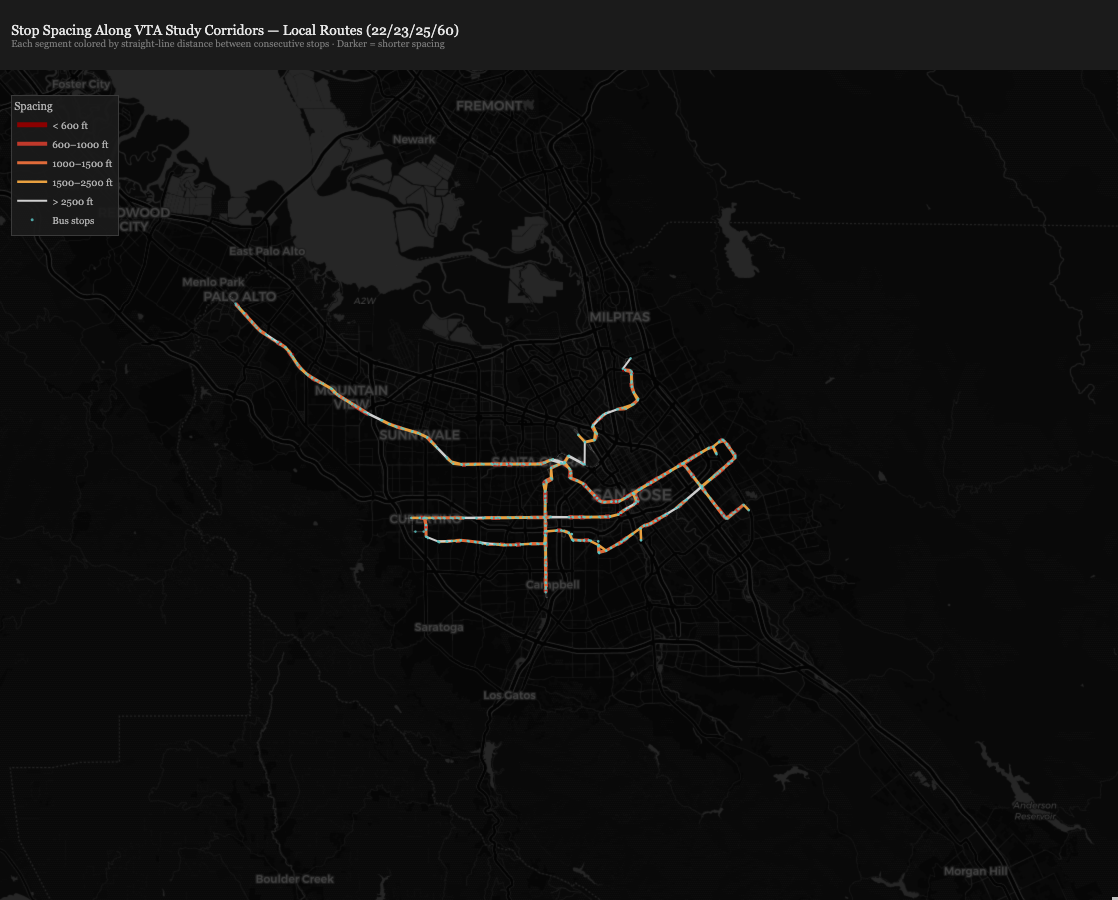

Saved: fig_05a_map_stop_spacing_local.html


In [78]:
fig7a = make_spacing_map(seg_df, LOCAL_ROUTES, "Local Routes (22/23/25/60)")
fig7a.show()
fig7a.write_html(VIZ / "fig_05a_map_stop_spacing_local.html", config={"scrollZoom": True})
print("Saved: fig_05a_map_stop_spacing_local.html")

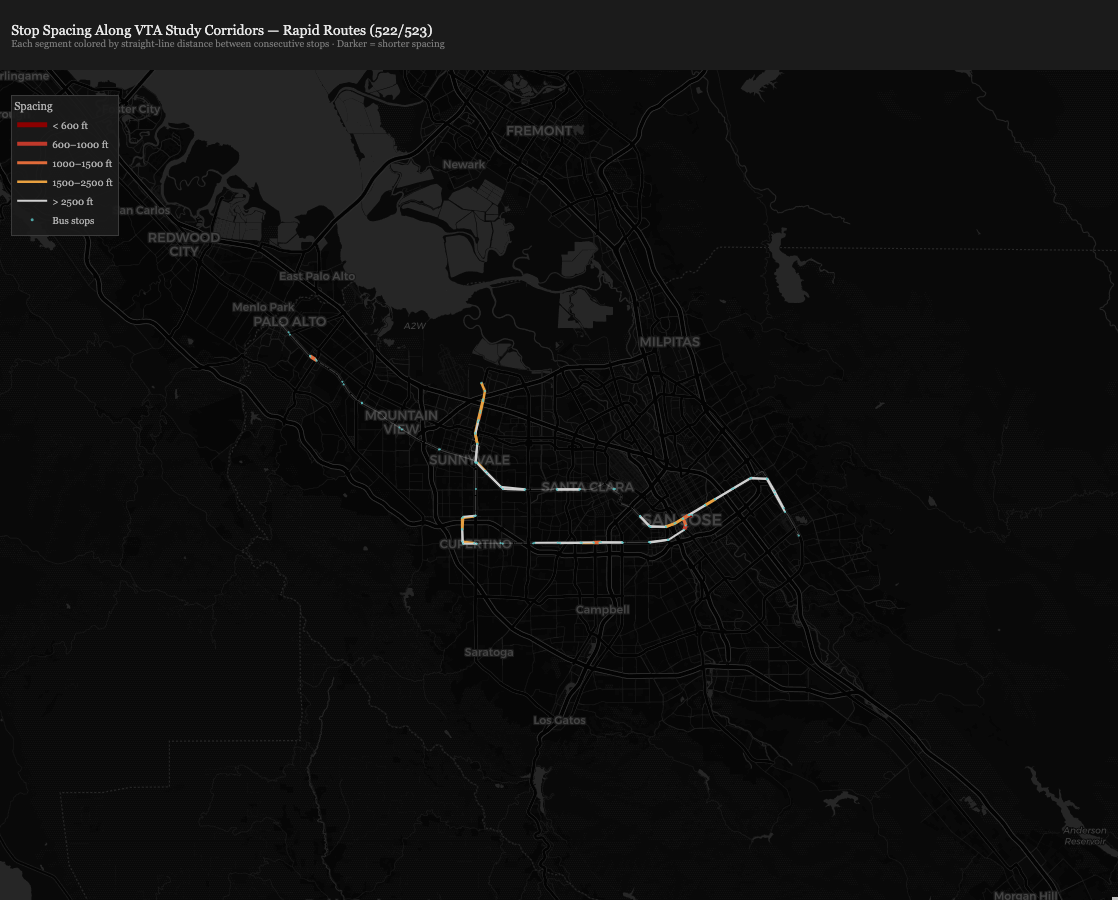

Saved: fig_05b_map_stop_spacing_rapid.html


In [79]:
fig7b = make_spacing_map(seg_df, RAPID_ROUTES, "Rapid Routes (522/523)")
fig7b.show()
fig7b.write_html(VIZ / "fig_05b_map_stop_spacing_rapid.html", config={"scrollZoom": True})
print("Saved: fig_05b_map_stop_spacing_rapid.html")

## 7. Figure 6 — Stop/Idle Share Grid: Low-Speed Hotspots (Interactive)

1200-ft grid aggregation of vehicle position pings.
Bubble size = share of near-stopped pings (speed < 0.5 mph); color = mean speed.
Grid aggregation reduces overplotting from ~80k raw GPS points.

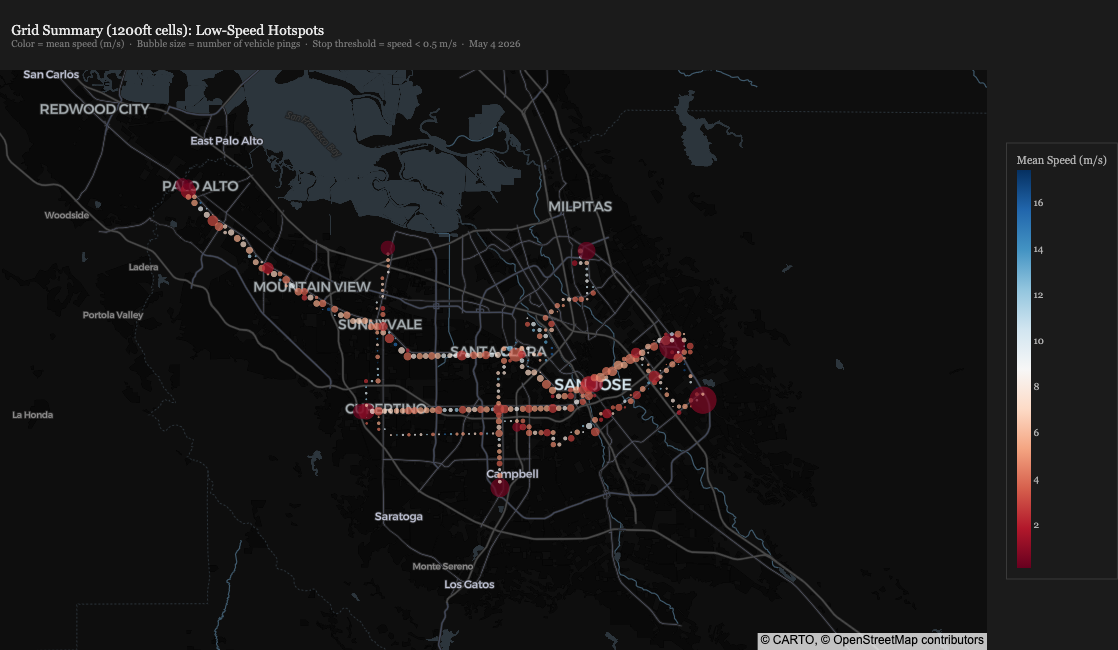

Saved: fig_06_map_grid_stopshare_1200ft.html


In [80]:
GRID_FT   = 1200
STOP_TH   = 0.5
MIN_PINGS = 20
 
veh = pd.read_csv(PROCESSED / "vehicle_points_filtered_buffer250ft.csv")
veh["speed"] = pd.to_numeric(veh["speed"], errors="coerce")
veh = veh.dropna(subset=["lat", "lon", "speed"])
veh = veh[veh["speed"] >= 0]
 
veh_gdf = gpd.GeoDataFrame(
    veh,
    geometry=gpd.points_from_xy(veh["lon"], veh["lat"]),
    crs="EPSG:4326",
).to_crs("EPSG:2227")
 
veh_gdf["gx"]      = (veh_gdf.geometry.x // GRID_FT) * GRID_FT
veh_gdf["gy"]      = (veh_gdf.geometry.y // GRID_FT) * GRID_FT
veh_gdf["is_stop"] = veh_gdf["speed"] < STOP_TH
 
grid = (
    veh_gdf.groupby(["gx", "gy"])
    .agg(mean_speed=("speed", "mean"),
         stop_share=("is_stop", "mean"),
         n=("speed", "size"))
    .reset_index()
)
grid = grid[grid["n"] >= MIN_PINGS].copy()
 
grid_gdf = gpd.GeoDataFrame(
    grid,
    geometry=gpd.points_from_xy(grid["gx"], grid["gy"]),
    crs="EPSG:2227",
).to_crs("EPSG:4326")
grid_gdf["lat"] = grid_gdf.geometry.y
grid_gdf["lon"] = grid_gdf.geometry.x
 
fig8 = px.scatter_map(
    grid_gdf,
    lat="lat", lon="lon",
    size="n",
    color="mean_speed",
    color_continuous_scale="RdBu",
    zoom=10,
    center={"lat": grid_gdf["lat"].mean(), "lon": grid_gdf["lon"].mean()},
    hover_data={
        "mean_speed": ":.2f",
        "stop_share": ":.2f",
        "n": True,
        "lat": False, "lon": False,
    },
    labels={
        "mean_speed": "Mean Speed (m/s)",
        "stop_share": "Stop Share",
        "n": "Pings",
    },
    title=(f"Grid Summary ({GRID_FT}ft cells): Low-Speed Hotspots<br>"
           f"<sup style='color:#777'>Color = mean speed (m/s)  ·  "
           f"Bubble size = number of vehicle pings  ·  "
           f"Stop threshold = speed < {STOP_TH} m/s  ·  May 4 2026</sup>"),
)
 
fig8.update_layout(
    map_style="carto-darkmatter",
    paper_bgcolor="#1b1b1b",
    font=dict(family="Georgia", color="#b0b0b0"),
    title=dict(
        font=dict(size=14, color="#e8e8e8", family="Georgia"),
        x=0.01, xanchor="left",
    ),
    coloraxis_colorbar=dict(
        title=dict(text="Mean Speed (m/s)",
                   font=dict(color="#b0b0b0", size=11, family="Georgia")),
        tickfont=dict(color="#b0b0b0", size=10, family="Georgia"),
        bgcolor="rgba(27,27,27,0.92)",
        bordercolor="#3a3a3a",
        borderwidth=1,
        thickness=14,
        len=0.75,
    ),
    margin=dict(l=0, r=0, t=70, b=0),
    height=650,
)
 
fig8.show()
fig8.write_html(VIZ / "fig_06_map_grid_stopshare_1200ft.html", config={"scrollZoom": True})
print("Saved: fig_06_map_grid_stopshare_1200ft.html")

## 8. Figure 7 — Stop Spacing vs. Mean Delay

Scatter plot testing RQ1. Points colored by route with OLS fit line.
Spearman correlation is reported alongside Pearson because Route 25 contains long-tail spacing outliers
from freeway-gap segments that distort the linear fit.

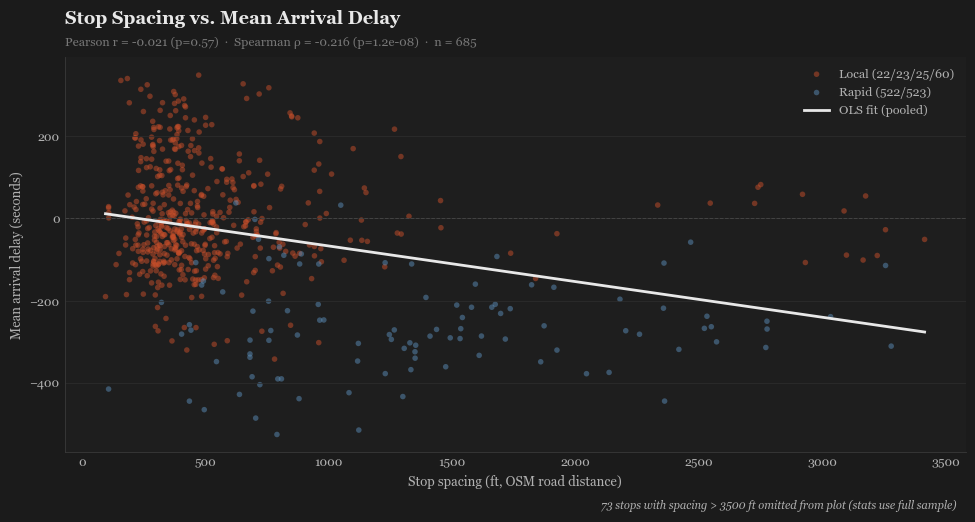

Saved: fig_07_scatter_spacing_vs_delay


In [81]:
spacing_full = gdf[gdf["spacing_ft"] > 0].copy()
spacing_full["route_type"] = np.where(
    spacing_full["route_id"].astype(str).str.contains("522|523"), "Rapid", "Local"
)

pearson_r5,  pearson_p5  = stats.pearsonr(spacing_full["spacing_ft"],  spacing_full["mean_delay_sec"])
spearman_r5, spearman_p5 = stats.spearmanr(spacing_full["spacing_ft"], spacing_full["mean_delay_sec"])
n5 = len(spacing_full)

spacing_plot = spacing_full[spacing_full["spacing_ft"] <= 3500]
n_capped5    = len(spacing_full) - len(spacing_plot)

fig5, ax = plt.subplots(figsize=(10, 5.5))

for label, color, marker_size in [
    ("Local (22/23/25/60)", C_LOCAL, 16),
    ("Rapid (522/523)",     C_RAPID, 16),
]:
    sub = spacing_plot[spacing_plot["route_type"] == label.split(" ")[0]]
    ax.scatter(sub["spacing_ft"], sub["mean_delay_sec"],
               s=marker_size, alpha=0.5, color=color, edgecolor="none", label=label)

ax.axhline(0, color=ZERO_CLR, linewidth=0.7, linestyle="--", alpha=0.6)

slope5, intercept5 = np.polyfit(spacing_plot["spacing_ft"], spacing_plot["mean_delay_sec"], 1)
xs5 = np.linspace(spacing_plot["spacing_ft"].min(), spacing_plot["spacing_ft"].max(), 100)
ax.plot(xs5, slope5 * xs5 + intercept5,
        color=TEXT1, linewidth=2, label="OLS fit (pooled)")

ax.set_xlabel("Stop spacing (ft, OSM road distance)")
ax.set_ylabel("Mean arrival delay (seconds)")
ax.grid(axis="y", zorder=0)

ax.set_title("Stop Spacing vs. Mean Arrival Delay", color=TEXT1)
ax.text(0, 1.02,
        f"Pearson r = {pearson_r5:+.3f} (p={pearson_p5:.2g})  ·  "
        f"Spearman ρ = {spearman_r5:+.3f} (p={spearman_p5:.2g})  ·  n = {n5}",
        transform=ax.transAxes, fontsize=9, color=TEXT3, ha="left", va="bottom")

if n_capped5:
    ax.text(0.99, -0.12,
            f"{n_capped5} stops with spacing > 3500 ft omitted from plot (stats use full sample)",
            transform=ax.transAxes, fontsize=8, style="italic",
            color=TEXT2, ha="right", va="top")

ax.legend(loc="upper right", fontsize=9, frameon=False, labelcolor=TEXT2)

fig5.tight_layout(pad=1.6)
fig5.savefig(VIZ / "fig_07_scatter_spacing_vs_delay.svg",
             bbox_inches="tight", facecolor=fig5.get_facecolor())
fig5.savefig(VIZ / "fig_07_scatter_spacing_vs_delay.png", dpi=200,
             bbox_inches="tight", facecolor=fig5.get_facecolor())
plt.show()
print("Saved: fig_07_scatter_spacing_vs_delay")

## 9. Figure 8 — Daily Boardings vs. Mean Delay

Scatter plot testing RQ2. Log scale on x-axis because boardings are right-skewed.
Negative association reflects that high-ridership stops are concentrated on Rapid 522/523
corridors that run ahead of conservative schedules.

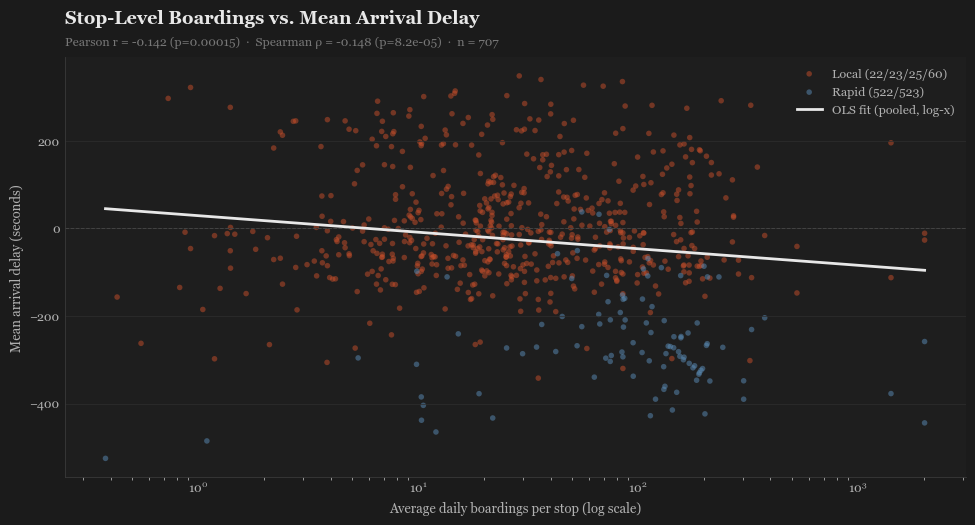

Saved: fig_08_scatter_boardings_vs_delay


In [82]:
boarding_full = gdf[gdf["boardings"] > 0].copy()
boarding_full["route_type"] = np.where(
    boarding_full["route_id"].astype(str).str.contains("522|523"), "Rapid", "Local"
)

pearson_r6,  pearson_p6  = stats.pearsonr(boarding_full["boardings"],  boarding_full["mean_delay_sec"])
spearman_r6, spearman_p6 = stats.spearmanr(boarding_full["boardings"], boarding_full["mean_delay_sec"])
n6 = len(boarding_full)

fig6, ax = plt.subplots(figsize=(10, 5.5))

for label, color in [("Local (22/23/25/60)", C_LOCAL),
                     ("Rapid (522/523)",     C_RAPID)]:
    sub = boarding_full[boarding_full["route_type"] == label.split(" ")[0]]
    ax.scatter(sub["boardings"], sub["mean_delay_sec"],
               s=16, alpha=0.5, color=color, edgecolor="none", label=label)

ax.axhline(0, color=ZERO_CLR, linewidth=0.7, linestyle="--", alpha=0.6)

log_x6 = np.log10(boarding_full["boardings"])
slope6, intercept6 = np.polyfit(log_x6, boarding_full["mean_delay_sec"], 1)
xs6 = np.linspace(log_x6.min(), log_x6.max(), 100)
ax.plot(10 ** xs6, slope6 * xs6 + intercept6,
        color=TEXT1, linewidth=2, label="OLS fit (pooled, log-x)")

ax.set_xscale("log")
ax.set_xlabel("Average daily boardings per stop (log scale)")
ax.set_ylabel("Mean arrival delay (seconds)")
ax.grid(axis="y", zorder=0)

ax.set_title("Stop-Level Boardings vs. Mean Arrival Delay", color=TEXT1)
ax.text(0, 1.02,
        f"Pearson r = {pearson_r6:+.3f} (p={pearson_p6:.2g})  ·  "
        f"Spearman ρ = {spearman_r6:+.3f} (p={spearman_p6:.2g})  ·  n = {n6}",
        transform=ax.transAxes, fontsize=9, color=TEXT3, ha="left", va="bottom")

ax.legend(loc="upper right", fontsize=9, frameon=False, labelcolor=TEXT2)

fig6.tight_layout(pad=1.6)
fig6.savefig(VIZ / "fig_08_scatter_boardings_vs_delay.svg",
             bbox_inches="tight", facecolor=fig6.get_facecolor())
fig6.savefig(VIZ / "fig_08_scatter_boardings_vs_delay.png", dpi=200,
             bbox_inches="tight", facecolor=fig6.get_facecolor())
plt.show()
print("Saved: fig_08_scatter_boardings_vs_delay")

## 10. Figure 9 — Ridership & Delay Bubble Map (Interactive)

Plotly Express bubble map. Bubble size = avg daily boardings; color = mean arrival delay.
Directly addresses RQ2 in spatial context. Red = late, green = early.

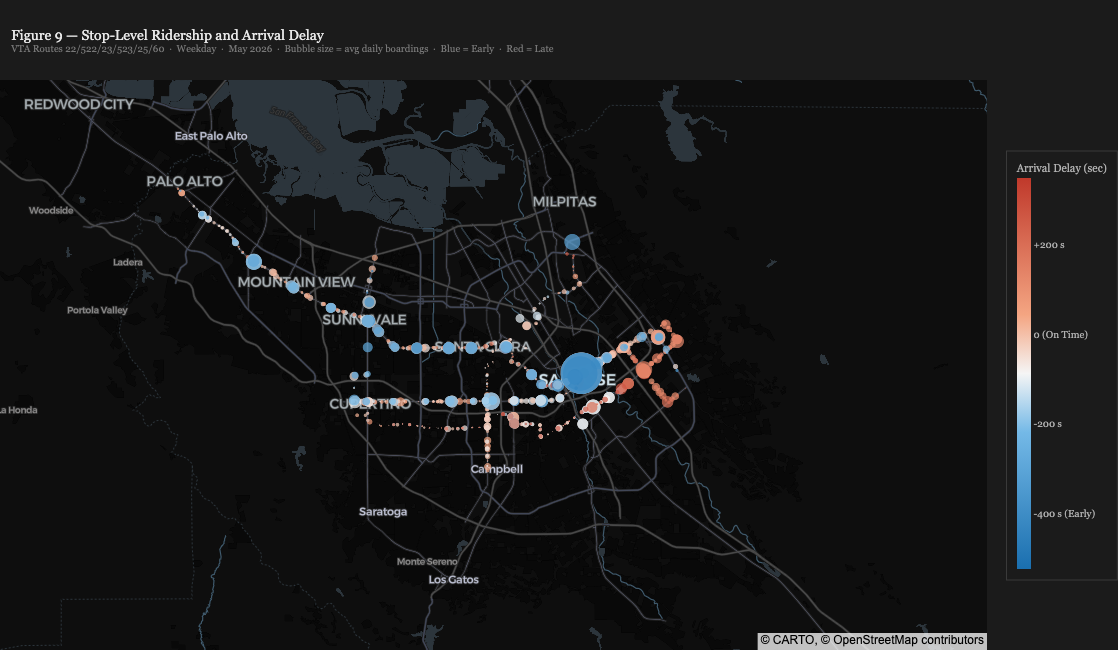

Saved: fig_09_map_bubble_ridership_delay.html


In [83]:
fig_bubble = px.scatter_map(
    gdf,
    lat="lat", lon="lon",
    size="boardings_rounded",
    color="mean_delay_sec",
    color_continuous_scale=[
        [0.0,  "#1a6faf"],
        [0.35, "#74b9e7"],
        [0.5,  "#f5f5f5"],
        [0.65, "#f4a582"],
        [1.0,  "#c0392b"],
    ],
    size_max=30,
    zoom=10,
    center={"lat": gdf["lat"].mean(), "lon": gdf["lon"].mean()},
    hover_name="stop_name",
    hover_data={
        "route_label":       True,
        "boardings_rounded": True,
        "mean_delay_sec":    True,
        "spacing_m":         True,
        "lat":               False,
        "lon":               False,
    },
    labels={
        "mean_delay_sec":    "Mean Delay (sec)",
        "boardings_rounded": "Avg Daily Boardings",
        "spacing_m":         "Stop Spacing (m)",
        "route_label":       "Route",
    },
    title=(
        "Figure 9 — Stop-Level Ridership and Arrival Delay<br>"
        "<sup style='color:#777'>VTA Routes 22/522/23/523/25/60  ·  Weekday  ·  May 2026  ·  "
        "Bubble size = avg daily boardings  ·  Blue = Early  ·  Red = Late</sup>"
    ),
)
 
fig_bubble.update_layout(
    map_style="carto-darkmatter",
    paper_bgcolor="#1b1b1b",
    font=dict(family="Georgia", color="#b0b0b0", size=12),
    title=dict(
        font=dict(size=14, color="#e8e8e8", family="Georgia"),
        x=0.01, xanchor="left",
    ),
    coloraxis_colorbar=dict(
        title=dict(
            text="Arrival Delay (sec)",
            font=dict(color="#b0b0b0", size=11, family="Georgia"),
        ),
        ticksuffix=" s",
        tickvals=[-400, -200, 0, 200, 400],
        ticktext=["-400 s (Early)", "-200 s", "0 (On Time)", "+200 s", "+400 s (Late)"],
        tickfont=dict(color="#b0b0b0", size=10, family="Georgia"),
        bgcolor="rgba(27,27,27,0.92)",
        bordercolor="#3a3a3a",
        borderwidth=1,
        thickness=14,
        len=0.75,
    ),
    margin=dict(l=0, r=0, t=80, b=0),
    height=650,
)
 
fig_bubble.show()
fig_bubble.write_html(
    VIZ / "fig_09_map_bubble_ridership_delay.html",
    config={"scrollZoom": True},
)
print("Saved: fig_09_map_bubble_ridership_delay.html")

## 11. Figure 10 — Delay Hotspots Overlaid with ADT (Interactive)

Two-layer Plotly map addressing RQ3.
Red markers = delay hotspot stops (top 25%); blue circles = San José ADT counters sized by volume.
Spatial overlap suggests locations where road traffic contributes to bus delay.

Delay hotspot threshold (75th percentile): 66.0 sec
Number of hotspot stops: 178


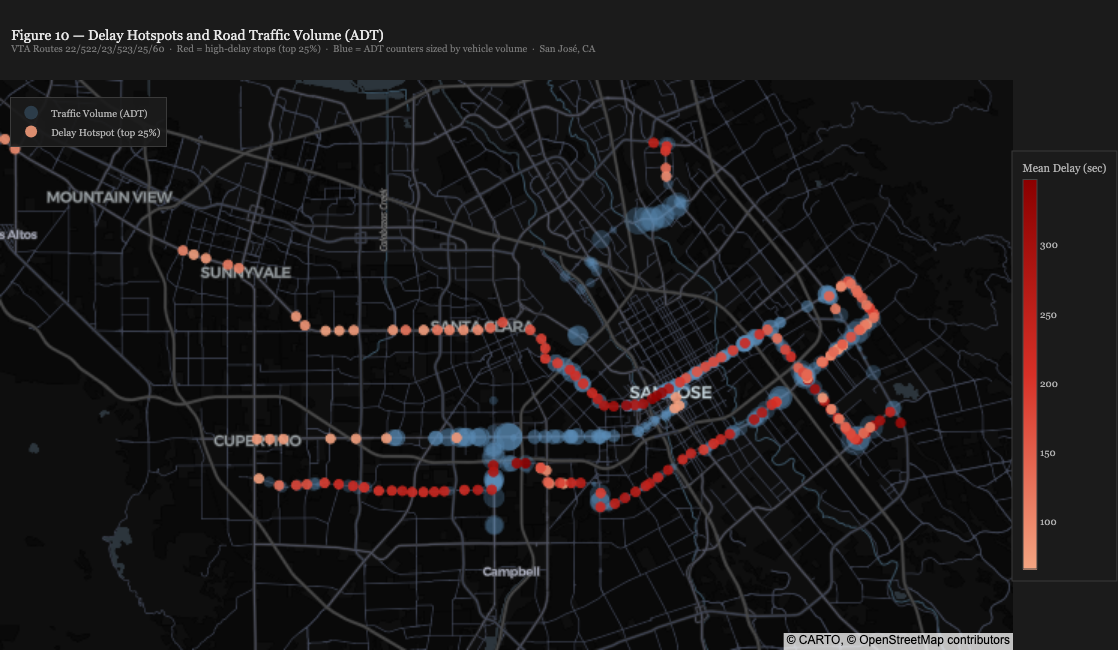

Saved: fig_10_map_delay_hotspot_adt.html


In [84]:
adt_df = pd.read_csv("../data/processed/selected_sj_adt.csv")
adt_df["geometry"] = adt_df["geometry"].apply(wkt.loads)
adt_gdf = gpd.GeoDataFrame(adt_df, geometry="geometry", crs="EPSG:2227")
adt_gdf = adt_gdf.to_crs("EPSG:4326")
adt_df["lat"] = adt_gdf.geometry.y
adt_df["lon"] = adt_gdf.geometry.x
adt_df = adt_df.dropna(subset=["adt"])

LAT_COL = "lat"
LON_COL = "lon"
ADT_COL = "adt"

delay_threshold = gdf["mean_delay_sec"].quantile(0.75)
hotspots = gdf[gdf["mean_delay_sec"] >= delay_threshold].copy()
print(f"Delay hotspot threshold (75th percentile): {delay_threshold:.1f} sec")
print(f"Number of hotspot stops: {len(hotspots)}")

fig_adt = go.Figure()

# ADT traffic volume bubbles
fig_adt.add_trace(go.Scattermap(
    lat=adt_df[LAT_COL], lon=adt_df[LON_COL],
    mode="markers",
    marker=dict(
        size=adt_df[ADT_COL] / adt_df[ADT_COL].max() * 25 + 5,
        color="#5b8db8",
        opacity=0.3,
    ),
    text=adt_df.apply(lambda r: f"ADT: {int(r[ADT_COL]):,} vehicles/day", axis=1),
    hoverinfo="text",
    name="Traffic Volume (ADT)",
))

# Delay hotspot stops
fig_adt.add_trace(go.Scattermap(
    lat=hotspots["lat"], lon=hotspots["lon"],
    mode="markers",
    marker=dict(
        size=12,
        color=hotspots["mean_delay_sec"],
        colorscale=[
            [0.0, "#f4a582"],
            [0.5, "#d73027"],
            [1.0, "#8b0000"],
        ],
        cmin=delay_threshold,
        cmax=hotspots["mean_delay_sec"].max(),
        colorbar=dict(
            title=dict(
                text="Mean Delay (sec)",
                font=dict(color="#b0b0b0", size=11, family="Georgia"),
            ),
            tickfont=dict(color="#b0b0b0", size=10, family="Georgia"),
            bgcolor="rgba(27,27,27,0.92)",
            bordercolor="#3a3a3a",
            borderwidth=1,
            thickness=14,
            len=0.75,
            x=1.0,
        ),
        opacity=0.9,
    ),
    text=hotspots.apply(
        lambda r: (f"{r['stop_name']}<br>"
                   f"Route {r['route_id']}<br>"
                   f"Delay: {r['mean_delay_sec']:.0f} sec<br>"
                   f"Boardings: {r['boardings_rounded']:.0f}/day"),
        axis=1,
    ),
    hoverinfo="text",
    name="Delay Hotspot (top 25%)",
))

fig_adt.update_layout(
    map_style="carto-darkmatter",
    map_zoom=11,
    map_center={"lat": gdf["lat"].mean(), "lon": gdf["lon"].mean()},
    paper_bgcolor="#1b1b1b",
    font=dict(family="Georgia", color="#b0b0b0", size=12),
    title=dict(
        text=(
            "Figure 10 — Delay Hotspots and Road Traffic Volume (ADT)<br>"
            "<sup style='color:#777'>VTA Routes 22/522/23/523/25/60  ·  "
            "Red = high-delay stops (top 25%)  ·  "
            "Blue = ADT counters sized by vehicle volume  ·  San José, CA</sup>"
        ),
        font=dict(size=14, color="#e8e8e8", family="Georgia"),
        x=0.01, xanchor="left",
    ),
    legend=dict(
        bgcolor="rgba(27,27,27,0.92)",
        bordercolor="#3a3a3a",
        borderwidth=1,
        font=dict(color="#b0b0b0", size=10, family="Georgia"),
        x=0.01, y=0.97,
    ),
    margin=dict(l=0, r=0, t=80, b=0),
    height=650,
)

fig_adt.show()
fig_adt.write_html(
    VIZ / "fig_10_map_delay_hotspot_adt.html",
    config={"scrollZoom": True},
)
print("Saved: fig_10_map_delay_hotspot_adt.html")